# <span style="color:teal"> Lezione 12 </span>
## <span style="color:turquoise"> Esercizio 12.1 </span>
In questo esercizio è stato chiesto di affrontare un problema di classificazione a 10 classi, addestrando una Rete Neurale Profonda (DNN) al riconoscimento delle cifre scritte a mano.  Il dataset impiegato è MNIST, una raccolta di 70.000 immagini in scala di grigi di dimensione 28×28 pixel. Oltre all'ottimizzatore SGD, sono stati selezionati e confrontati altri tre ottimizzatori: Adam, RMSprop e Adagrad. L'obiettivo è di valutarne le differenze in termini di velocità di convergenza e capacità di generalizzazione.

In [1]:
import tensorflow as tf
from tensorflow import keras
import os
import numpy as np
import matplotlib.pyplot as plt

# fix del seed per garantire riproducibilità dei risultati
seed=0
np.random.seed(seed)
tf.random.set_seed(seed)

#### Step 1: Caricamento ed elaborazione dei dati

Keras permette di scaricare automaticamente il dataset MNIST dalla rete. Il dataset è già suddiviso internamente in un set di training e uno di test, il che facilita il confronto delle performance tra modelli diversi su dati standardizzati.

Dopo il caricamento, i dati vengono pre-elaborati per essere nel formato corretto atteso dalla rete neurale. Poiché le immagini MNIST sono in scala di grigi, hanno un solo canale colore e dimensione 28×28×1, quindi vengono appiattite in vettori 1D da 784 elementi come richiesto dai layer Dense. Se invece fossero state a colori con 3 canali RGB, il vettore di input sarebbe stato di 28×28×3 = 2352 elementi.
I valori dei pixel vengono poi convertiti in float32 e normalizzati dall'intervallo [0, 255] a [0, 1], migliorando così la stabilità numerica e la velocità di convergenza. Infine, le label vengono convertite in formato one-hot encoding: ad esempio la cifra 3 diventa [0, 0, 0, 1, 0, 0, 0, 0, 0, 0], rappresentazione necessaria per utilizzare la categorical crossentropy come funzione di loss.

In [2]:
# Import dei dati da keras e divido in train e test

from keras.datasets import mnist


# Dimensioni delle immagini in input: 28x28 pixel
img_rows, img_cols = 28, 28
# Numero di classi in output: 10 cifre (0-9)
num_classes = 10

# Caricamento del dataset, già suddiviso in training e test
(X_train, Y_train), (X_test, Y_test) = mnist.load_data()

In [3]:
# metto dati nel format corretto

# reshape data, it could depend on Keras backend
X_train = X_train.reshape(X_train.shape[0], img_rows*img_cols)
X_test = X_test.reshape(X_test.shape[0], img_rows*img_cols)

# cast to floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# rescale data in interval [0,1]
# perchè ciascun pixel è codificato a 8 bit con valori compresi nell'intervallo [0, 255]
# dove 0 corrisponde al nero assoluto e 255 al bianco assoluto
X_train /= 255
X_test /= 255

# convert class vectors to binary class matrices, e.g. for use with categorical_crossentropy
Y_train = keras.utils.to_categorical(Y_train, num_classes)
Y_test = keras.utils.to_categorical(Y_test, num_classes)

#### Step 2: Definizione della Rete Neurale e della sua architettura

Per costruire la DNN si utilizza la classe `Sequential()`, che permette di definire il modello come una sequenza lineare di layer, e il metodo `add()` per aggiungere i layer uno alla volta. Ogni layer `Dense()` riceve come argomenti il numero di neuroni e la funzione di attivazione.
La forma dell'input viene specificata esplicitamente nel primo layer tramite `Input(shape=(784,))`, corrispondente ai 784 pixel di ciascuna immagine. La struttura sequenziale del modello permette a Keras di propagare automaticamente le dimensioni corrette di input e output tra tutti i layer nascosti, senza doverle specificare manualmente per ciascuno.
L'architettura è composta da due layer nascosti `Dense` con funzione di attivazione *ReLU*, rispettivamente da 400 e 100 neuroni. Dopo il secondo layer nascosto viene applicato un layer di `Dropout` con tasso 0.5, che durante il training disattiva casualmente la metà dei neuroni ad ogni iterazione, riducendo il rischio di overfitting. Il layer di output è un Dense con 10 neuroni, uno per ciascuna cifra, con funzione di attivazione Softmax, che restituisce una distribuzione di probabilità sulle 10 classi.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input

def create_DNN():
    # instantiate model
    model = Sequential()
    model.add(Input(shape=(img_rows*img_cols,)))
    
    # add a dense all-to-all relu layer
    model.add(Dense(400, activation='relu'))
    
    # add a dense all-to-all relu layer
    model.add(Dense(100, activation='relu'))
    
    # apply dropout with rate 0.5
    model.add(Dropout(0.5))
    
    # soft-max layer
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

print('Model architecture created successfully!')

Model architecture created successfully!


#### Step 3: Scelta dell'ottimizzatore e della funzione costo

Tutti i modelli vengono compilati e addestrati nello stesso modo, con l'unica differenza dell'ottimizzatore utilizzato. Come funzione di loss viene scelta la `categorical_crossentropy`, che rappresenta la scelta standard per i problemi di classificazione multiclasse quando le label sono in formato one-hot encoding. Come metrica di valutazione viene utilizzata l'`accuracy`, ovvero la percentuale di campioni classificati correttamente. Il modello viene compilato tramite il metodo `compile()`, a cui vengono passati come argomenti l'ottimizzatore, la funzione di loss e la metrica di validazione.

I quattro ottimizzatori confrontati sono SGD, Adam, RMSprop e Adagrad, ciascuno inizializzato con i propri iperparametri e salvato nei dizionari `histories` e `models` per il confronto successivo.

#### Step 4: Allenamento del modello

Ogni modello viene addestrato in modalità mini-batch, con `batch_size=32`, per $25$ epoche. I dati di training vengono mescolati ad ogni epoca tramite `shuffle=True`, il che migliora la stabilità dell'addestramento evitando che il modello apprenda dipendenze legate all'ordine dei campioni. Ogni epoca corrisponde a un passaggio completo su tutti i dati di training, suddivisi in mini-batch da $32$ campioni.

Per addestrare il modello si utilizza il metodo `fit()` della classe `Sequential`, a cui vengono passati i dati di input e output, la dimensione dei mini-batch, il numero di epoche, i dati di test come validation_data per monitorare le performance ad ogni epoca, e `verbose=1` per visualizzare il progresso del training.

In [5]:
#parametri comuni a tutti gli ottimizzatori

from keras.optimizers import SGD, Adam, RMSprop, Adagrad, Adadelta, Adamax, Nadam

batch_size = 32
epochs = 25
histories = {}
models = {}

- **SGD (Stochastic Gradient Descent)**

    Ad ogni iterazione SGD aggiorna i pesi della rete nella direzione opposta al gradiente della funzione di loss, calcolato su un mini-batch di campioni anziché sull'intero dataset.
    Vengono scelti i seguenti iperparametri:
    - `learning_rate = 0.008`: controlla la dimensione del passo di aggiornamento dei pesi ad ogni iterazione. Un valore troppo alto rischia di non convergere, mentre un valore troppo basso rallenta eccessivamente il training. Il valore di $0.008$ rappresenta un buon compromesso per MNIST con questa architettura.
  
    - `momentum = 0.2`: accumula una frazione del gradiente dei passi precedenti, dando una sorta di "inerzia" all'aggiornamento dei pesi. Questo permette di smorzare le oscillazioni e accelerare la convergenza nelle direzioni rilevanti, specialmente in presenza di gradienti rumorosi. Con un valore di $0.2$, si vuole sfruttare l'effetto stabilizzante del momentum per ridurre le oscillazioni tipiche di SGD, senza però rischiare che un valore troppo alto spinga il modello a convergere in modo aggressivo verso i dati di training, favorendo l'overfitting.

In [6]:
#SGD
name = "SGD"
opt = tf.keras.optimizers.SGD(learning_rate=0.008, momentum=0.2)

print(f"Inizio training con {name}")
model = create_DNN()
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['acc'])
histories[name] = model.fit(X_train, Y_train,
      batch_size=batch_size,
      epochs=epochs,
      shuffle=True,
      verbose=1,
      validation_data=(X_test, Y_test))
models[name] = model
print(f"Fine training con {name}")

Inizio training con SGD
Epoch 1/25


2026-06-09 12:42:45.358376: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.7717 - loss: 0.7754 - val_acc: 0.9114 - val_loss: 0.3168
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.8885 - loss: 0.3903 - val_acc: 0.9307 - val_loss: 0.2416
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9108 - loss: 0.3132 - val_acc: 0.9397 - val_loss: 0.2044
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9245 - loss: 0.2679 - val_acc: 0.9473 - val_loss: 0.1779
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9342 - loss: 0.2341 - val_acc: 0.9513 - val_loss: 0.1587
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9406 - loss: 0.2113 - val_acc: 0.9552 - val_loss: 0.1454
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - acc: 0.9456 - loss: 0.1934 - val_acc: 0.9586 - val_loss: 0.1337
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc: 0.9501 - loss: 0.1762 - val_acc: 0.9616 - val_loss: 0.1241
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4m

- **RMSprop (Root Mean Square Propagation)**
  
    RMSprop è un ottimizzatore adattivo che mantiene una media mobile dei quadrati dei gradienti recenti e la utilizza per normalizzare il learning rate di ciascun parametro, rendendolo più stabile e adatto a situazioni in cui i gradienti variano molto tra un'iterazione e l'altra. Vengono scelti i seguenti iperparametri:

    - `learning_rate = 0.0001`: è stato scelto un valore più basso rispetto al default (0.001), poiché con quel valore la validation loss risultava molto instabile, con oscillazioni marcate nel corso delle epoche. Abbassare il learning rate ha stabilizzato significativamente il comportamento del modello.
      
    - `rho = 0.3`: è il fattore di decadimento della media mobile dei gradienti al quadrato, che bilancia la reattività ai gradienti correnti con la memoria di quelli passati. In questo caso, è stato scelto un valore basso come $0.3$ per ridurre il peso della storia dei gradienti passati, rendendo l'ottimizzatore più reattivo ai gradienti correnti. Rispetto al valore standard di 0.9, questa scelta ha prodotto una migliore accuracy, una loss più bassa e un minor gap tra training e validation, riducendo il fenomeno dell'overfitting.

In [7]:
#RMSprop
name = "RMSprop"
opt = tf.keras.optimizers.RMSprop(learning_rate=0.0001, rho=0.3)

print(f"Inizio training con {name}")
model = create_DNN()
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['acc'])
histories[name] = model.fit(X_train, Y_train,
      batch_size=batch_size,
      epochs=epochs,
      shuffle=True,
      verbose=1,
      validation_data=(X_test, Y_test))
models[name] = model
print(f"Fine training con {name}")

Inizio training con RMSprop
Epoch 1/25


2026-06-09 12:46:27.498002: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.7979 - loss: 0.6940 - val_acc: 0.9199 - val_loss: 0.2738
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9051 - loss: 0.3319 - val_acc: 0.9366 - val_loss: 0.2112
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9276 - loss: 0.2642 - val_acc: 0.9451 - val_loss: 0.1828
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9382 - loss: 0.2298 - val_acc: 0.9517 - val_loss: 0.1675
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9444 - loss: 0.2065 - val_acc: 0.9561 - val_loss: 0.1520
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9508 - loss: 0.1872 - val_acc: 0.9599 - val_loss: 0.1423
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9554 - loss: 0.1729 - val_acc: 0.9625 - val_loss: 0.1354
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9573 - loss: 0.1653 - val_acc: 0.9654 - val_loss: 0.1296
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1

- **Adam (Adaptive Moment Estimation)**
  
    Adam è un ottimizzatore che combina due metodi: il momentum, che accumula i gradienti passati per dare inerzia all'aggiornamento, e RMSprop, che adatta il learning rate in modo diverso per ciascun parametro della rete in base alla magnitude dei gradienti recenti. Viene scelto il seguente iperparametro:

    - `learning_rate = 0.00004`: rispetto al valore di default di Adam (0.001), è stato scelto un valore più basso per ridurre il rischio di overfitting osservato nei tentativi precedenti, in cui la validation loss tendeva a risalire nelle epoche successive. Un learning rate più conservativo rallenta leggermente la convergenza ma garantisce una maggiore stabilità e una migliore generalizzazione sul dataset di test.
    - `beta_1 = 0.2`:  controlla la media mobile del gradiente, ovvero quanta "memoria" dei gradienti passati viene mantenuta ad ogni aggiornamento dei pesi. Un valore alto (come il default 0.9) conferisce molta inerzia all'ottimizzatore, che rischia di convergere in modo aggressivo verso i dati di training favorendo l'overfitting. Con un valore di $0.2$, l'ottimizzatore è molto più reattivo al gradiente corrente e meno influenzato dalla storia passata, il che ha contribuito a ridurre il gap tra training e validation loss osservato con i valori di default.

In [8]:
#Adam
name = "Adam"
opt = tf.keras.optimizers.Adam(learning_rate=0.00004, beta_1=0.2)

print(f"Inizio training con {name}")
model = create_DNN()
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['acc'])
histories[name] = model.fit(X_train, Y_train,
      batch_size=batch_size,
      epochs=epochs,
      shuffle=True,
      verbose=1,
      validation_data=(X_test, Y_test))
models[name] = model
print(f"Fine training con {name}")

Inizio training con Adam
Epoch 1/25


2026-06-09 12:51:01.266539: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - acc: 0.7358 - loss: 0.9199 - val_acc: 0.9089 - val_loss: 0.3571
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.8835 - loss: 0.4203 - val_acc: 0.9298 - val_loss: 0.2565
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9093 - loss: 0.3286 - val_acc: 0.9381 - val_loss: 0.2128
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9233 - loss: 0.2780 - val_acc: 0.9473 - val_loss: 0.1852
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9340 - loss: 0.2396 - val_acc: 0.9519 - val_loss: 0.1636
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9403 - loss: 0.2131 - val_acc: 0.9559 - val_loss: 0.1490
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9472 - loss: 0.1921 - val_acc: 0.9594 - val_loss: 0.1366
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9513 - loss: 0.1761 - val_acc: 0.9622 - val_loss: 0.1270
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1

- **Adagrad (Adaptive Gradient Algorithm)**

    Adagrad è un ottimizzatore adattivo che riduce automaticamente il learning rate nel tempo per ciascun parametro, accumulando i gradienti passati. Tende però a far decrescere il learning rate troppo aggressivamente nelle fasi avanzate del training. Viene scelto il seguente iperparametro:

    - `learning_rate = 0.01`: è il valore di default consigliato per Adagrad. Poiché l'algoritmo riduce automaticamente il learning rate nel corso del training, non è necessario partire da un valore basso come per Adam e RMSprop.

In [9]:
#Adagrad
name = "Adagrad"
opt = tf.keras.optimizers.Adagrad(learning_rate=0.01)

print(f"Inizio training con {name}")
model = create_DNN()
model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['acc'])
histories[name] = model.fit(X_train, Y_train,
      batch_size=batch_size,
      epochs=epochs,
      shuffle=True,
      verbose=1,
      validation_data=(X_test, Y_test))
models[name] = model
print(f"Fine training con {name}")

Inizio training con Adagrad
Epoch 1/25


2026-06-09 12:55:50.103971: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 188160000 exceeds 10% of free system memory.


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - acc: 0.8519 - loss: 0.5089 - val_acc: 0.9357 - val_loss: 0.2205
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - acc: 0.9237 - loss: 0.2703 - val_acc: 0.9499 - val_loss: 0.1683
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9401 - loss: 0.2111 - val_acc: 0.9591 - val_loss: 0.1390
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - acc: 0.9499 - loss: 0.1790 - val_acc: 0.9632 - val_loss: 0.1236
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9564 - loss: 0.1550 - val_acc: 0.9656 - val_loss: 0.1115
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9607 - loss: 0.1400 - val_acc: 0.9688 - val_loss: 0.1024
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - acc: 0.9642 - loss: 0.1272 - val_acc: 0.9709 - val_loss: 0.0949
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - acc: 0.9682 - loss: 0.1153 - val_acc: 0.9722 - val_loss: 0.0907
Epoch 9/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1

#### Step 5: Valutazione delle performance sul dataset di test

Una volta completato il training, ogni modello viene valutato sui dati di test, ovvero dati mai visti durante l'addestramento, tramite il metodo `evaluate()`, che restituisce il valore della loss e dell'accuracy sul set di test. Per visualizzare e confrontare l'andamento del training, vengono inoltre prodotti i grafici di accuracy e loss per ciascun ottimizzatore, sia sul set di training che sul set di test, permettendo di analizzare la velocità di convergenza, la stabilità dell'addestramento e l'eventuale presenza di overfitting.

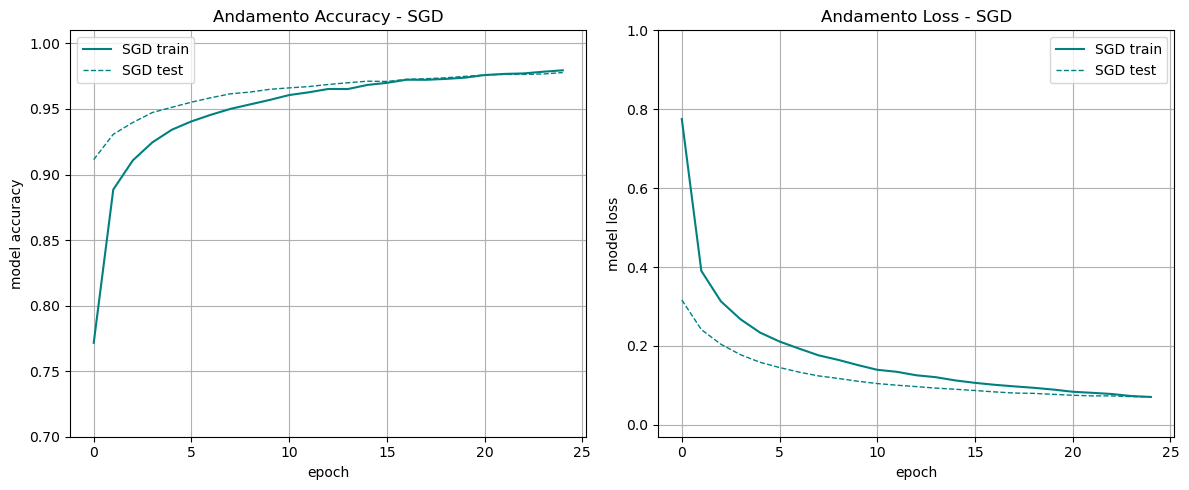

In [10]:
# plot confronto accuracy e loss SGD
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

hist = histories["SGD"]

# accuracy
ax1.plot(hist.history['acc'],     color="teal", linestyle='-', lw=1.5, label='SGD train')
ax1.plot(hist.history['val_acc'], color="teal", linestyle='--', lw=1,  label='SGD test')
# loss
ax2.plot(hist.history['loss'],     color="teal", linestyle='-', lw=1.5, label='SGD train')
ax2.plot(hist.history['val_loss'], color="teal", linestyle='--', lw=1,  label='SGD test')

ax1.set_ylabel('model accuracy')
ax1.set_xlabel('epoch')
ax1.set_title("Andamento Accuracy - SGD")
ax1.legend(loc='best')
ax1.set_ylim(0.7, 1.010)
ax1.grid()

ax2.set_ylabel('model loss')
ax2.set_xlabel('epoch')
ax2.set_title("Andamento Loss - SGD")
ax2.legend(loc='best')
ax2.set_ylim(-0.030, 1)
ax2.grid()

plt.tight_layout()
plt.show()

I grafici mostrano un andamento molto positivo per SGD. L'accuracy parte da circa il 77% sul set di training e cresce regolarmente fino al 97-98%, mentre sul set di test parte già più alta (circa 91%) grazie al Dropout disattivato durante la valutazione. Anche la loss scende in modo fluido e senza oscillazioni su entrambi i set, confermando che gli iperparametri scelti sono ben calibrati. L'aspetto più rilevante è che le curve di training e test convergono e si sovrappongono nelle epoche finali senza che si osservi alcuna risalita della loss di test, indicando una completa assenza di overfitting e una buona capacità di generalizzazione del modello.

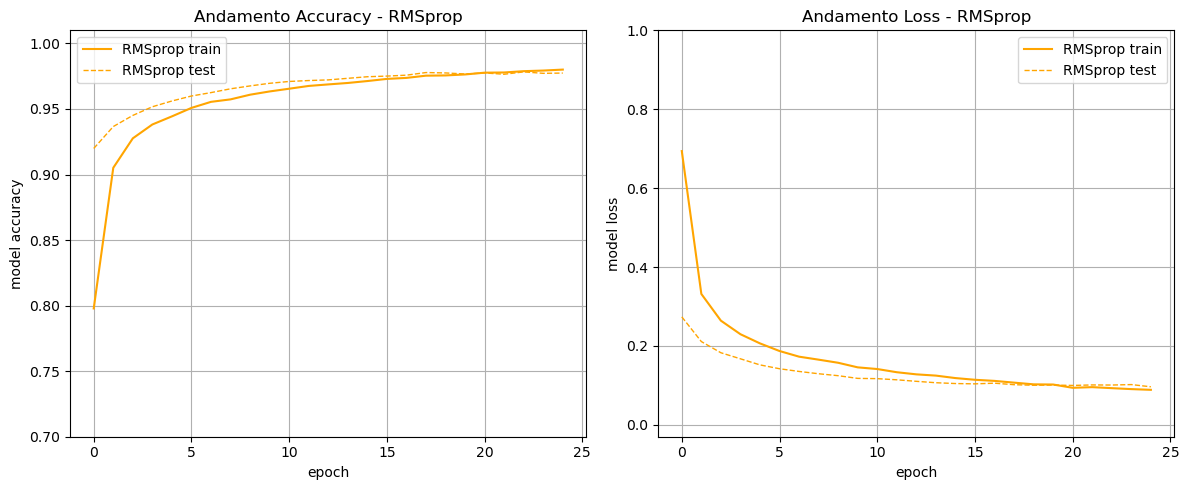

In [11]:
# plot confronto accuracy e loss RMSprop
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

hist = histories["RMSprop"]

# accuracy
ax1.plot(hist.history['acc'],     color="orange", linestyle='-', lw=1.5, label='RMSprop train')
ax1.plot(hist.history['val_acc'], color="orange", linestyle='--', lw=1,  label='RMSprop test')
# loss
ax2.plot(hist.history['loss'],     color="orange", linestyle='-', lw=1.5, label='RMSprop train')
ax2.plot(hist.history['val_loss'], color="orange", linestyle='--', lw=1,  label='RMSprop test')

ax1.set_ylabel('model accuracy')
ax1.set_xlabel('epoch')
ax1.set_title("Andamento Accuracy - RMSprop")
ax1.legend(loc='best')
ax1.set_ylim(0.7, 1.010)
ax1.grid()

ax2.set_ylabel('model loss')
ax2.set_xlabel('epoch')
ax2.set_title("Andamento Loss - RMSprop")
ax2.legend(loc='best')
ax2.set_ylim(-0.030, 1)
ax2.grid()

plt.tight_layout()
plt.show()

I grafici mostrano un andamento molto positivo per RMSprop. L'accuracy parte da circa l'80% sul set di training e cresce rapidamente fino al 97-98%, mentre sul set di test parte già più alta (circa 92%) grazie al Dropout disattivato durante la valutazione. Anche la loss scende in modo rapido e fluido su entrambi i set, con una discesa iniziale particolarmente ripida nelle prime epoche. L'aspetto più rilevante è che le curve di training e test convergono progressivamente fino a sovrapporsi nelle epoche finali, senza alcuna risalita della loss di test, indicando una completa assenza di overfitting e una buona capacità di generalizzazione del modello.

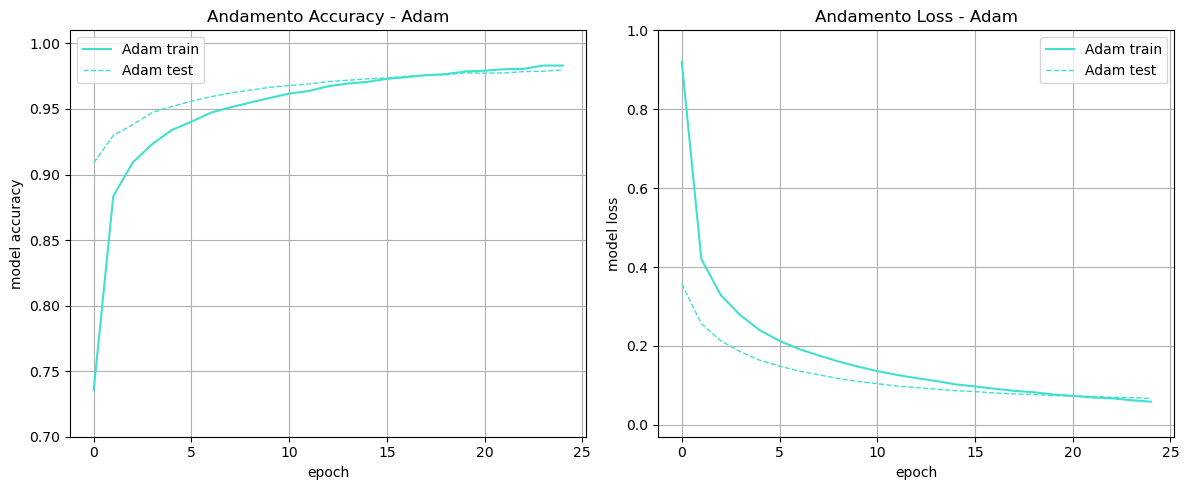

In [12]:
# plot confronto accuracy e loss Adam
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

hist = histories["Adam"]

# accuracy
ax1.plot(hist.history['acc'],     color="turquoise", linestyle='-', lw=1.5, label='Adam train')
ax1.plot(hist.history['val_acc'], color="turquoise", linestyle='--', lw=1,  label='Adam test')
# loss
ax2.plot(hist.history['loss'],     color="turquoise", linestyle='-', lw=1.5, label='Adam train')
ax2.plot(hist.history['val_loss'], color="turquoise", linestyle='--', lw=1,  label='Adam test')

ax1.set_ylabel('model accuracy')
ax1.set_xlabel('epoch')
ax1.set_title("Andamento Accuracy - Adam")
ax1.legend(loc='best')
ax1.set_ylim(0.7, 1.010)
ax1.grid()

ax2.set_ylabel('model loss')
ax2.set_xlabel('epoch')
ax2.set_title("Andamento Loss - Adam")
ax2.legend(loc='best')
ax2.set_ylim(-0.030, 1)
ax2.grid()

plt.tight_layout()
plt.show()

I grafici mostrano un andamento molto positivo per Adam. L'accuracy parte da circa il 74% sul set di training e cresce rapidamente fino al 97-98%, mentre sul set di test parte già più alta (circa 91%) grazie al Dropout disattivato durante la valutazione. La loss di training parte da un valore iniziale molto alto (circa ~0.95) e scende in modo rapido e continuo su entrambi i set. Da notare che nella fase iniziale il gap tra training e test è più pronunciato rispetto agli altri ottimizzatori, ma si riduce progressivamente fino a che le curve convergono e si sovrappongono nelle epoche finali. L'assenza di qualsiasi risalita della loss di test indica una completa assenza di overfitting e una buona capacità di generalizzazione del modello.

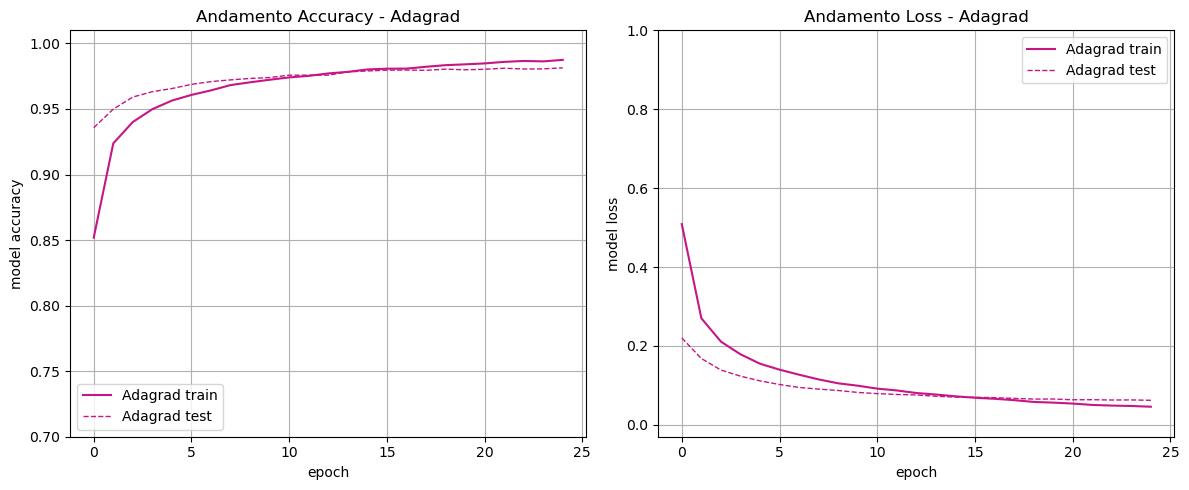

In [13]:
# plot confronto accuracy e loss Adagrad
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

hist = histories["Adagrad"]

# accuracy
ax1.plot(hist.history['acc'],     color="mediumvioletred", linestyle='-', lw=1.5, label='Adagrad train')
ax1.plot(hist.history['val_acc'], color="mediumvioletred", linestyle='--', lw=1,  label='Adagrad test')
# loss
ax2.plot(hist.history['loss'],     color="mediumvioletred", linestyle='-', lw=1.5, label='Adagrad train')
ax2.plot(hist.history['val_loss'], color="mediumvioletred", linestyle='--', lw=1,  label='Adagrad test')

ax1.set_ylabel('model accuracy')
ax1.set_xlabel('epoch')
ax1.set_title("Andamento Accuracy - Adagrad")
ax1.legend(loc='best')
ax1.set_ylim(0.7, 1.010)
ax1.grid()

ax2.set_ylabel('model loss')
ax2.set_xlabel('epoch')
ax2.set_title("Andamento Loss - Adagrad")
ax2.legend(loc='best')
ax2.set_ylim(-0.030, 1)
ax2.grid()

plt.tight_layout()
plt.show()

I grafici mostrano un andamento molto positivo per Adagrad. L'accuracy parte da circa l'85% sul training set e cresce in modo graduale e regolare fino al 97-98%, mentre sul test set parte già più alta (circa 94%) grazie al Dropout disattivato durante la valutazione. La loss parte da circa ~0.52 e scende in modo fluido e continuo su entrambi i set. Le curve di training e test sono particolarmente vicine per tutta la durata del training, con un gap minimo nelle prime epoche che si riduce progressivamente fino alla quasi completa sovrapposizione nelle epoche finali. Questo indica un overfitting molto lieve e assolutamente trascurabile, con una buona capacità di generalizzazione del modello.

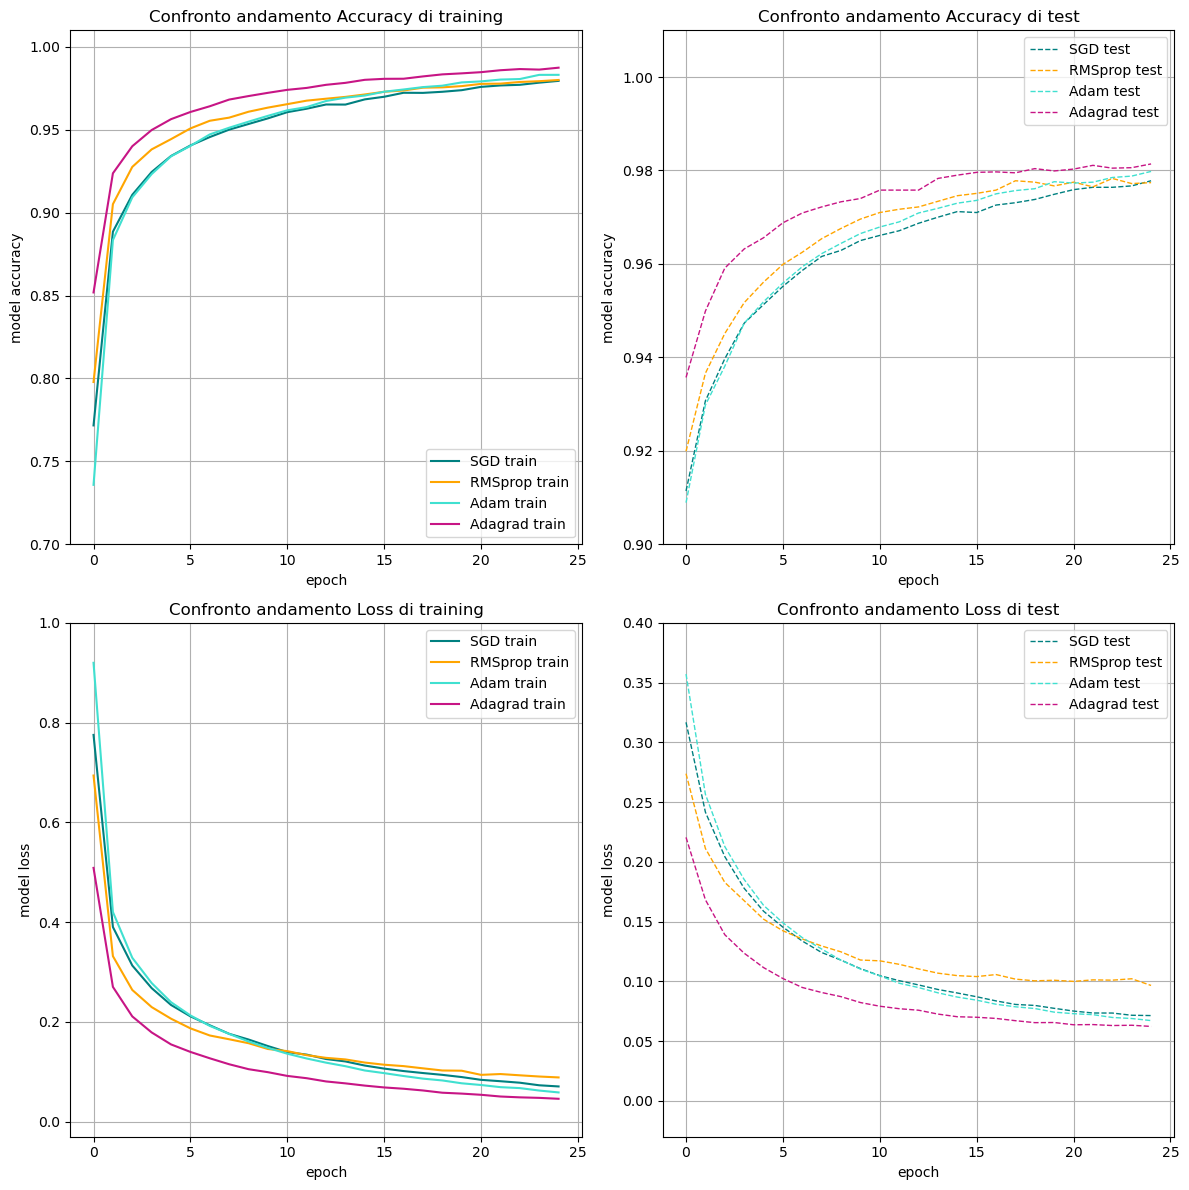

In [14]:
# Valutazione del modello e confronto grafico loss e accuracy

# plot confronto accuracy e loss
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 12))
colors = {"SGD": "teal", "Adam": "turquoise", "RMSprop": "orange", "Adagrad": "mediumvioletred" }

for name, hist in histories.items():
    # accuracy
    ax1.plot(hist.history['acc'],     color=colors[name], linestyle='-', lw=1.5,  label=f'{name} train')
    ax2.plot(hist.history['val_acc'], color=colors[name], linestyle='--', lw=1, label=f'{name} test')
    # loss
    ax3.plot(hist.history['loss'],         color=colors[name], linestyle='-', lw=1.5, label=f'{name} train')
    ax4.plot(hist.history['val_loss'],     color=colors[name], linestyle='--', lw=1, label=f'{name} test')

ax1.set_ylabel('model accuracy')
ax1.set_xlabel('epoch')
ax1.set_title("Confronto andamento Accuracy di training")
ax1.legend(loc='best')
ax1.set_ylim(0.7, 1.010)
ax1.grid()

ax2.set_ylabel('model accuracy')
ax2.set_xlabel('epoch')
ax2.set_title("Confronto andamento Accuracy di test")
ax2.legend(loc='best')
ax2.set_ylim(0.9, 1.010)
ax2.grid()

ax3.set_ylabel('model loss')
ax3.set_xlabel('epoch')
ax3.set_title("Confronto andamento Loss di training")
ax3.legend(loc='best')
ax3.set_ylim(-0.030, 1)
ax3.grid()

ax4.set_ylabel('model loss')
ax4.set_xlabel('epoch')
ax4.set_title("Confronto andamento Loss di test")
ax4.legend(loc='best')
ax4.set_ylim(-0.030, 0.4)
ax4.grid()

plt.tight_layout()
plt.show()

I grafici di confronto permettono di osservare le differenze di comportamento tra SGD, RMSprop, Adam e Adagrad sia sul set di training che su quello di test.

Per quanto riguarda la velocità di convergenza, Adagrad si distingue nettamente dagli altri: già nelle primissime epoche raggiunge valori di accuracy e loss molto migliori rispetto agli altri ottimizzatori, grazie alla sua capacità di ridurre progressivamente il learning rate per ciascun parametro. RMSprop e Adam mostrano una convergenza iniziale simile e più rapida rispetto a SGD, che risulta il più lento nelle prime epoche ma raggiunge comunque valori competitivi nelle epoche finali.

Osservando i valori finali, tutti e quattro gli ottimizzatori convergono verso un'accuracy di circa 97-98%, il che indica che l'architettura della rete è sufficientemente capace indipendentemente dall'ottimizzatore scelto. Tuttavia, Adagrad raggiunge i valori migliori sia in termini di accuracy che di loss sul set di test, con una loss finale che scende verso ~0.06, mentre SGD, RMSprop e Adam si attestano intorno a ~0.07-0.10.

Dal grafico della loss di test, emerge chiaramente come Adagrad si separi dagli altri già dopo le prime epoche, mantenendo una loss sistematicamente più bassa per tutta la durata del training. RMSprop e SGD mostrano un andamento molto simile tra loro, mentre Adam presenta una loss di test leggermente più alta nelle epoche finali nonostante una convergenza inizialmente più rapida.

In [15]:
# evaluate models
for name, hist in histories.items():
    score = models[name].evaluate(X_test, Y_test, verbose=1)
    print(f'[{name}] Test loss:', score[0])
    print(f'[{name}] Test accuracy:', score[1])
    print()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9778 - loss: 0.0714
[SGD] Test loss: 0.07137370109558105
[SGD] Test accuracy: 0.9778000116348267

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9774 - loss: 0.0966
[RMSprop] Test loss: 0.09657367318868637
[RMSprop] Test accuracy: 0.977400004863739

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9798 - loss: 0.0672
[Adam] Test loss: 0.06717889755964279
[Adam] Test accuracy: 0.9797999858856201

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - acc: 0.9814 - loss: 0.0623
[Adagrad] Test loss: 0.062296491116285324
[Adagrad] Test accuracy: 0.9814000129699707



I risultati numerici finali confermano quanto osservato nei grafici: Adagrad ottiene sia la test accuracy più alta (98.14%) che la test loss più bassa (0.0623), confermandosi il migliore tra i quattro ottimizzatori. Adam si posiziona secondo con una accuracy del 97.98% e una loss di 0.0672, seguito da SGD con il 97.78% e una loss di 0.0714. RMSprop risulta il meno performante con una accuracy del 97.74% e la loss più alta (0.0966). In generale tutti gli ottimizzatori generalizzano bene sul dataset di test senza segni evidenti di overfitting, grazie anche al layer di Dropout presente nell'architettura.

#### Step 6: Visualizzazione delle predizioni
Come verifica finale, per ciascun ottimizzatore vengono visualizzate le predizioni sui primi 10 campioni del test set. Per ogni immagine viene mostrata la cifra reale e quella predetta dal modello, con il titolo colorato in verde se la predizione è corretta e in rosso in caso contrario. 

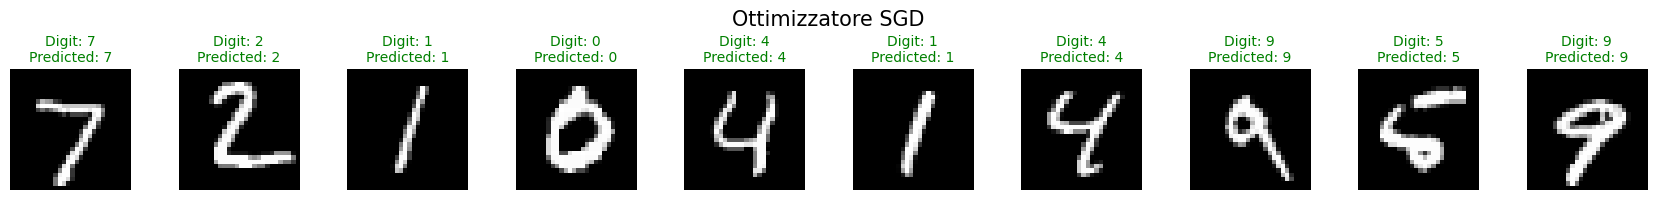

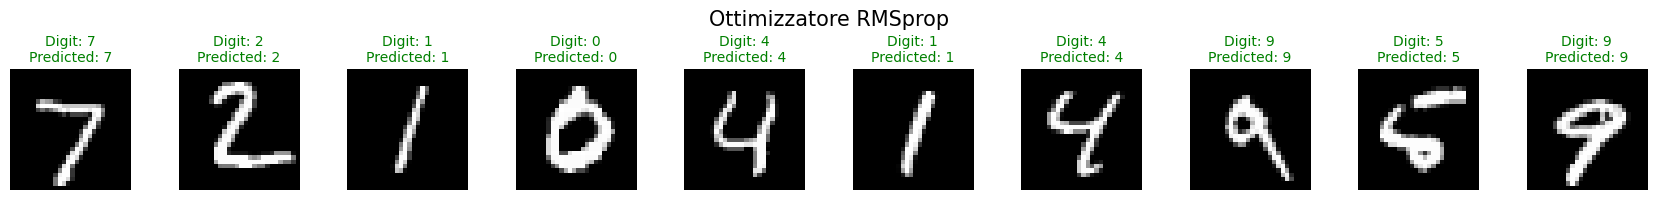

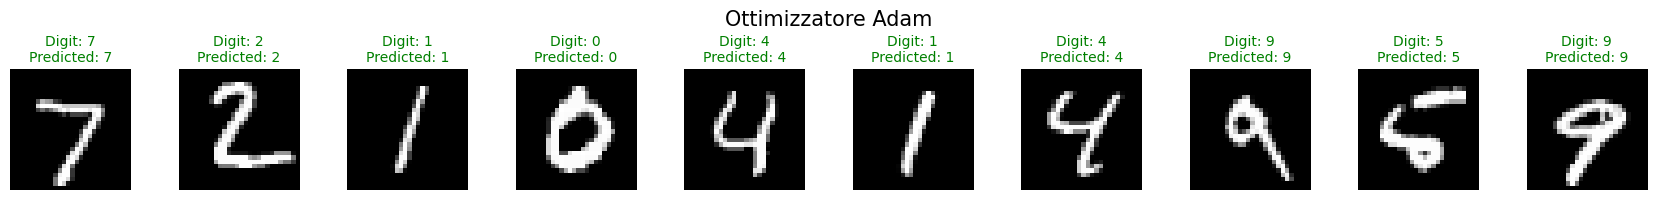

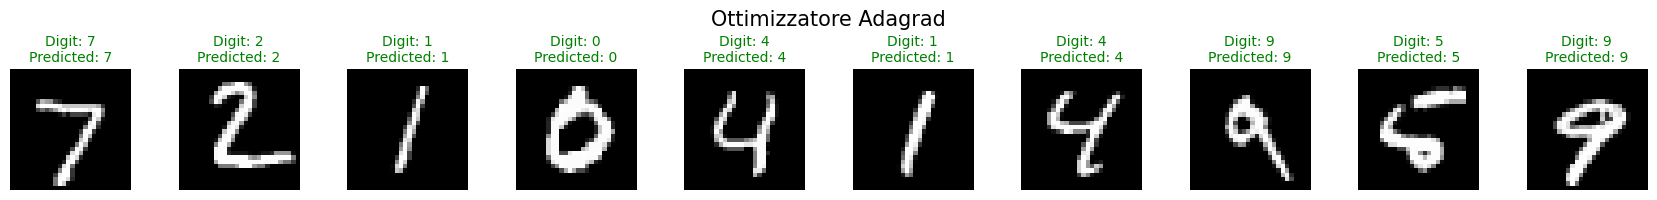

In [16]:
# visualizzazione predizioni
X_test_img = X_test.reshape(X_test.shape[0], img_rows, img_cols, 1)

for name, model in models.items():
    predictions = model.predict(X_test, verbose=0)
    
    plt.figure(figsize=(17, 2))
    plt.suptitle(f"Ottimizzatore {name}", fontsize=15)
    
    for i in range(10):
        ax = plt.subplot(1, 10, i + 1)
        plt.imshow(X_test_img[i, :, :, 0], cmap='gray')
        
        true_label = np.argmax(Y_test[i])
        pred_label = np.argmax(predictions[i])
        correct = true_label == pred_label
        
        plt.title(f"Digit: {true_label}\nPredicted: {pred_label}", fontsize=10,
                  color='green' if correct else 'red')
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

Come si può osservare dalle immagini, tutti e quattro i modelli classificano correttamente tutte le 10 cifre mostrate, confermando le buone performance già osservate nelle metriche di valutazione.

## <span style="color:turquoise"> Esercizio 12.2 </span>
In questo esercizio è stato chiesto di modificare l'architettura della Rete Neurale Profonda (DNN) sviluppata nell'esercizio precedente, sostituendola con una Rete Neurale Convoluzionale (CNN). Il modello è stato addestrato sul dataset MNIST con ottimizzatore SGD e le sue prestazioni sono state messe a confronto con quelle del DNN precedente.

#### Step 1: Caricamento ed elaborazione dei dati
A differenza del DNN fully-connected, che appiattiva le immagini in un vettore monodimensionale perdendo le relazioni spaziali tra i pixel, la CNN sfrutta la struttura bidimensionale delle immagini attraverso layer `Conv2D`, che applicano filtri locali per estrarre automaticamente feature come bordi, curve e forme.

Un cambiamento fondamentale rispetto all'esercizio precedente riguarda infatti la forma dei dati in input. Nel DNN i dati venivano appiattiti in vettori di 784 elementi (28×28 = 784), mentre la CNN richiede che le immagini mantengano la loro struttura spaziale. Per questo motivo i dati vengono ridimensionati da (N, 784) a (N, 28, 28, 1), dove N è il numero di campioni, 28×28 sono le dimensioni spaziali dell'immagine e 1 è il numero di canali (in questo caso un solo canale per la scala di grigi).

In [17]:
# reshape dei dati
from keras.layers import Conv2D, MaxPooling2D, Flatten

# input_shape per immagini 28x28 grayscale
img_rows, img_cols = 28, 28
input_shape = (img_rows, img_cols, 1)

# reshape dei dati: da (N, 784) a (N, 28, 28, 1)
X_train_cnn = X_train.reshape(X_train.shape[0], img_rows, img_cols, 1).astype('float32')
X_test_cnn  = X_test.reshape(X_test.shape[0],  img_rows, img_cols, 1).astype('float32')

#### Step 2: Definizione della Rete Neurale e della sua architettura
L'architettura della CNN è costruita con due blocchi convoluzionali seguiti da una parte fully-connected finale.
Il primo blocco applica 10 filtri di dimensione 5×5 con attivazione ReLU, seguito da un `MaxPooling2D` con finestra 2×2 che dimezza le dimensioni spaziali, e un `Dropout(0.25)` per ridurre l'overfitting. Il secondo blocco aumenta la profondità a 20 filtri di dimensione 3×3, di nuovo seguito da `MaxPooling2D` e `Dropout(0.25)`.

Dopo i due blocchi convoluzionali, un layer `Flatten` converte le feature map tridimensionali in un vettore monodimensionale, che viene poi passato a un layer `Dense` da 128 neuroni con ReLU e un `Dropout(0.5)` più aggressivo prima del layer di output. Quest'ultimo è un `Dense` da 10 neuroni con attivazione `softmax`, che produce una distribuzione di probabilità sulle 10 cifre possibili.

#### Step 3: Scelta dell'ottimizzatore e della funzione costo
Il modello viene compilato con `categorical_crossentropy` come funzione di loss e SGD come ottimizzatore, con gli stessi parametri usati nell'esercizio precedente (`learning_rate=0.008` e `momentum=0.2`) per rendere il confronto tra DNN e CNN il più equo possibile.

In [18]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, Input
from keras.layers import Conv2D, MaxPooling2D, Flatten, Input

def create_CNN():
    model = Sequential()

    # Input esplicito
    model.add(Input(shape=(img_rows, img_cols, 1)))

    # Primo blocco conv
    model.add(Conv2D(10, kernel_size=(5, 5), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Secondo blocco conv
    model.add(Conv2D(20, kernel_size=(3, 3), activation='relu'))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Flatten + Dense
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(Dropout(0.5))

    # Output softmax
    model.add(Dense(num_classes, activation='softmax'))

    model.compile(loss=keras.losses.categorical_crossentropy,
              optimizer=tf.keras.optimizers.SGD(learning_rate=0.008, momentum=0.2),
              metrics=['acc'])
    
    return model

#### Step 4: Allenamento del modello

Il modello viene addestrato in modalità mini-batch, con `batch_size=32`, per $25$ epoche. I dati di training vengono mescolati ad ogni epoca tramite `shuffle=True`.

Per addestrare il modello si utilizza il metodo `fit()` della classe `Sequential`, a cui vengono passati i dati di input e output, la dimensione dei mini-batch, il numero di epoche, i dati di test come validation_data per monitorare le performance ad ogni epoca, e `verbose=1` per visualizzare il progresso del training.

In [32]:
batch_size = 32
epochs = 25

# Crea e addestra la CNN
model_CNN = create_CNN()

history_CNN = model_CNN.fit(X_train_cnn, Y_train,
              batch_size=batch_size,
              epochs=epochs,
              shuffle=True,
              verbose=1,
              validation_data=(X_test_cnn, Y_test))


Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 9ms/step - acc: 0.6643 - loss: 0.9941 - val_acc: 0.9371 - val_loss: 0.2370
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - acc: 0.8844 - loss: 0.3735 - val_acc: 0.9605 - val_loss: 0.1365
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9150 - loss: 0.2760 - val_acc: 0.9687 - val_loss: 0.1039
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9307 - loss: 0.2287 - val_acc: 0.9736 - val_loss: 0.0875
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - acc: 0.9377 - loss: 0.2034 - val_acc: 0.9769 - val_loss: 0.0757
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.9443 - loss: 0.1824 - val_acc: 0.9792 - val_loss: 0.0677
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 18s 10ms/step - acc: 0.9493 - loss: 0.1693 - val_acc: 0.9797 - val_loss: 0.0641
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - acc: 0.9514 - loss: 0.1595 - val_acc: 0.9809 - val_loss: 0.0585
Epoch 9/25
1875/1875 ━━━━━━

#### Step 5: Valutazione delle performance sul dataset di test

Una volta completato il training, il modello viene valutato sui dati di test, ovvero dati mai visti durante l'addestramento, tramite il metodo `evaluate()`, che restituisce il valore della loss e dell'accuracy sul test set.

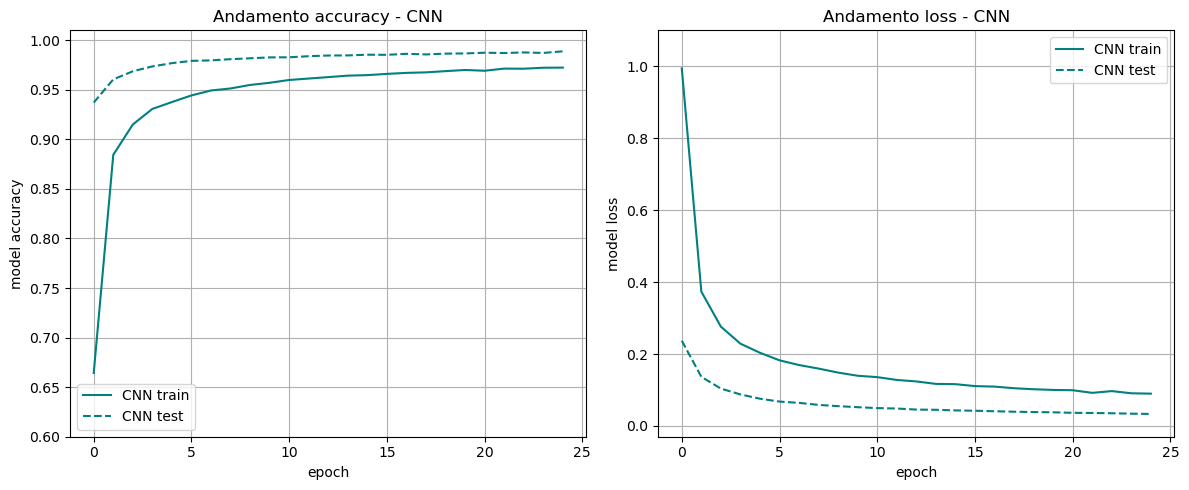

In [34]:
# Plot accuracy e loss
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

hist = history_CNN

ax1.plot(hist.history['acc'],     color='teal', linestyle='-',  lw=1.5, label='CNN train')
ax1.plot(hist.history['val_acc'], color='teal', linestyle='--', lw=1.5,   label='CNN test')
ax1.set_ylabel('model accuracy')
ax1.set_xlabel('epoch')
ax1.set_title("Andamento accuracy - CNN")
ax1.legend(loc='best')
ax1.set_ylim(0.6, 1.010)
ax1.grid()

ax2.plot(hist.history['loss'],     color='teal', linestyle='-',  lw=1.5, label='CNN train')
ax2.plot(hist.history['val_loss'], color='teal', linestyle='--', lw=1.5,   label='CNN test')
ax2.set_ylabel('model loss')
ax2.set_xlabel('epoch')
ax2.set_title("Andamento loss - CNN")
ax2.legend(loc='best')
ax2.set_ylim(-0.030, 1.1)
ax2.grid()

plt.tight_layout()
plt.show()

I grafici mostrano un netto miglioramento rispetto ai risultati ottenuti con il DNN nell'esercizio precedente. L'accuracy sul training parte da circa il 65% e cresce rapidamente fino al 97%, mentre il set di test parte già da un valore molto alto (circa 95%) e si stabilizza intorno al 98.5% già dopo poche epoche.  
La loss sul training parte da un valore elevato (circa 1.05) e scende in modo rapido e continuo, mentre quella sul test parte già molto bassa (circa 0.20) e converge verso valori prossimi a 0.02 nelle epoche finali. 

Si osserva come l'accuracy di training rimanga al di sotto di quella di test e, analogamente, la loss di training sopra quella di test. Questo comportamento è dovuto al `Dropout`, che è attivo solo durante il training e disattiva casualmente una frazione dei neuroni ad ogni batch, penalizzando artificialmente le prestazioni sul set di training. Invece, durante la valutazione sul set di test il `Dropout` viene automaticamente disabilitato da Keras, permettendo al modello di usare tutti i neuroni e ottenendo quindi prestazioni più alte. Questo meccanismo rende il modello più robusto e generalizzabile, prevenendo l'overfitting.



In [35]:
# Valutazione
score = model_CNN.evaluate(X_test_cnn, Y_test, verbose=1)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - acc: 0.9888 - loss: 0.0333
Test loss:     0.033324308693408966
Test accuracy: 0.9887999892234802


La CNN guadagna circa +1% di accuracy rispetto al DNN dell'esercizio precedente con lo stesso ottimizzatore e con lo stesso numero di epoche (97.8% vs 98.9%). La loss si riduce di circa la metà (0.071 vs 0.033), a conferma che la CNN non solo classifica meglio ma lo fa con maggiore sicurezza. Questo miglioramento è interamente attribuibile all'architettura convoluzionale, che riesce a estrarre feature spaziali significative dalle immagini in modo molto più efficace rispetto ai layer fully-connected del DNN.

## <span style="color:turquoise"> Esercizio 12.3 </span>
In questo esercizio è stato chiesto di verificare se la CNN costruita nell'esercizio precedente è in grado di riconoscere 10 cifre scritte a mano da me. In figura per ogni immagine verrà mostrata la cifra reale e quella predetta dal modello, con il titolo colorato in verde se la predizione è corretta e in rosso in caso contrario. 

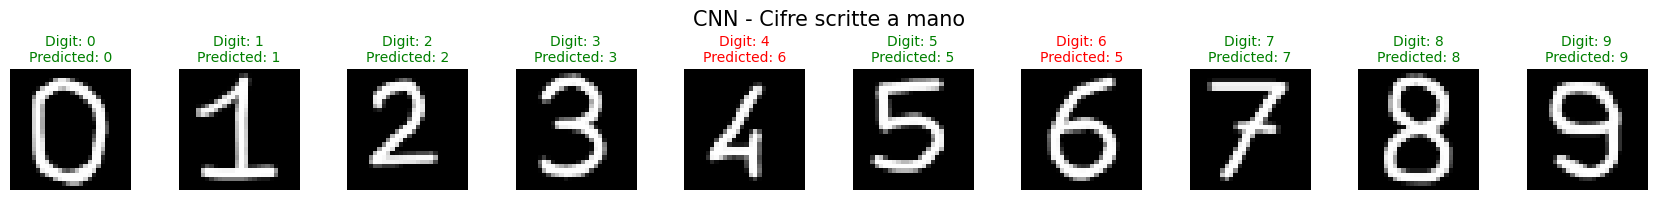

In [40]:
# importo le mie immagini e faccio test CNN
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os

img_rows, img_cols = 28, 28
files = ["numeri/num0.png","numeri/num1.png","numeri/num2.png","numeri/num3.png","numeri/num4.png",
         "numeri/num5.png","numeri/num6.png","numeri/num7.png","numeri/num8.png","numeri/num9.png",]

immagini = []  # conterrà i pixel normalizzati di ogni immagine
nomi = []      # conterrà l'etichetta vera di ogni immagine (0-9)

for fname in files:
    digit_in = Image.open(fname).convert('L')  # apro l'immagine e la converto in scala di grigi
    ydim, xdim = digit_in.size                 # recupero le dimensioni (larghezza, altezza)
    pix = digit_in.load()                      # carico i pixel dell'immagine
    data = np.zeros((xdim, ydim))              # creo una matrice vuota per i valori dei pixel
    
    for j in range(ydim):
        for i in range(xdim):
            data[i, j] = pix[j, i]            # copio i pixel nella matrice (trasposta per allineare righe/colonne)
    
    data /= 255                                # normalizzo i valori nell'intervallo [0, 1]
    immagini.append(data)
    nomi.append(fname.split("/")[-1].replace('.png', '').replace('num', ''))  # estraggo il nome

immagini = np.array(immagini)
immagini_cnn = immagini.reshape(immagini.shape[0], img_rows, img_cols, 1)

predictions = model_CNN.predict(immagini_cnn, verbose=0)

plt.figure(figsize=(17, 2))
plt.suptitle("CNN - Cifre scritte a mano", fontsize=15)

for i in range(len(files)):
    true_label = int(nomi[i])
    pred_label = np.argmax(predictions[i])
    correct = true_label == pred_label

    plt.subplot(1, len(files), i + 1)
    plt.imshow(immagini[i], cmap='gray')
    plt.title(f"Digit: {true_label}\nPredicted: {pred_label}", fontsize=10,
              color='green' if correct else 'red')
    plt.axis('off')

plt.tight_layout()
plt.show()

Come si può osservare dalla figura, la CNN commette due errori di classificazione: il 4 viene classificato come 6 e il 6 viene classificato come 5. Questi errori sono probabilmente dovuti al fatto che le cifre che ho disegnato a mano presentano uno stile che si discosta da quello tipico del dataset MNIST.  
In particolare, il 4 è stato tracciato con una forma più chiusa e meno "squadrata" rispetto alle stesse cifre di MNIST, con la parte superiore leggera e quella inferiore più piena, caratteristiche che il modello ha interpretato come quelle di un 6. Il 6, invece, presenta una parte circolare inferiore molto più grande rispetto a quella tipica delle cifre MNIST, alterando le proporzioni a cui il modello è abituato e portandolo a confonderlo con un 5.  
Nonostante questi errori, le restanti 8 cifre vengono classificate correttamente, confermando una buona capacità di generalizzazione del modello.